# **Bayesian analysis in Python**

Bayesian Analysis in Python

Bayesian analysis is a statistical framework used to estimate unknown parameters and measure uncertainty. It is different from the frequentist approach, although both methods are rigorous and useful in many situations.

In many cases, Bayesian and frequentist methods can lead to similar conclusions. However, they differ in how they define uncertainty and in the computational methods they use. Bayesian analysis often requires specialized algorithms and software packages, such as PyStan, PyMC, or similar tools.

This notebook introduces some key ideas in Bayesian analysis. It does not provide a complete guide to applying Bayesian methods in practice.

Key Notation and Terminology

In Bayesian statistics, we usually want to learn about an unknown parameter, represented by:

θ: the unknown parameter we want to estimate.

D: the observed data.

The goal is to use the data D to learn about θ and understand how uncertain we are about its value.

Likelihood: p(D | θ)

The likelihood is the probability of observing the data D, assuming a specific value of the parameter θ.

In simple words:

How likely is the data, given this parameter value?

Prior distribution: p(θ)

The prior represents what we believe or know about θ before seeing the data.

In simple words:

What do we believe about the parameter before using the data?

Posterior distribution: p(θ | D)

The posterior is the updated belief about θ after combining the prior information with the observed data.

In simple words:

What do we know about the parameter after seeing the data?

Evidence: p(D)

The evidence is the overall probability of observing the data, considering all possible values of θ.

In practice, it is often used as a normalizing constant.

Bayes’ Theorem

Bayesian analysis is based on Bayes’ theorem:

[
p(\theta|D) = \frac{p(D|\theta)p(\theta)}{p(D)}
]

This means:

[
Posterior = \frac{Likelihood \times Prior}{Evidence}
]

In practice, we often focus on the proportional relationship:

[
p(\theta|D) \propto p(D|\theta) \times p(\theta)
]

This means that the posterior distribution is proportional to the likelihood multiplied by the prior.

Simple Interpretation

Bayesian analysis updates our previous beliefs using new data.

A simple way to remember it is:

[
Prior + Data = Posterior
]

So, Bayesian inference combines what we already believe with what the data tells us.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st


## **Coin - Flipping Problem**

We will illustrate these ideas in the context of a coin-flipping experiment.

For a fair coin, the sample space is {_heads_, _tails_}, and each of these outcomes has probability 1/2.

Now suppose that we have a coin and don't know whether it is fair.  The actual probability of this coin landing heads-up is the parameter $\theta$.

The exact value of $\theta$ can never be known, but we are able to conduct an experiment where we flip this coin $n$ times and observe $x$ heads and $n-x$ tails.  In the notation introduced above, the data $D$ is $(x, n)$.  

The likelihood $p(D|\theta)$ is a single number that captures how well the data match the parameter value $\theta$.

We first discuss the likelihood function, which plays a key role in both frequentist and Bayesian analysis.  We illustrate the likelihood function using the Python function `lf_plot` below.  This function plots the binomial likelihood function for each possible value of the parameter $\theta$, for three given values of $x$, and three different sample sizes $n$.

In [ ]:
def lf_plot(n):
    theta = np.linspace(0.01, 0.99, 100)
    for x in np.floor(np.r_[0.2, 0.5, 0.6]*n):
        l = st.binom.pmf(x, n, theta)
        plt.grid(True)
        plt.plot(theta, l, "-", label="%.0f" % x)
        plt.xlabel(r"$\theta$", size=15)
        plt.ylabel("Log likelihood", size=15)
    ha, lb = plt.gca().get_legend_handles_labels()
    plt.figlegend(ha, lb, "center right")

The likelihood function shows which values of \theta make the observed data most likely.

If you toss a coin n times and get x heads, the observed proportion is:

\frac{x}{n}

The likelihood is highest when:

\theta = \frac{x}{n}

This value is called the Maximum Likelihood Estimate (MLE).

For binomial data:

\hat{\theta} = \frac{x}{n}

Example:

If you get 60 heads in 100 tosses:

\hat{\theta} = \frac{60}{100} = 0.60

So the best estimate of the probability of heads is 0.60.

When the sample size n is larger, the likelihood curve becomes narrower and more concentrated around the MLE. This means the estimate is more precise.

Main idea:

\text{larger sample size} \Rightarrow \text{more information} \Rightarrow \text{more precise estimate}

TypeError: legend() takes 0-2 positional arguments but 3 were given

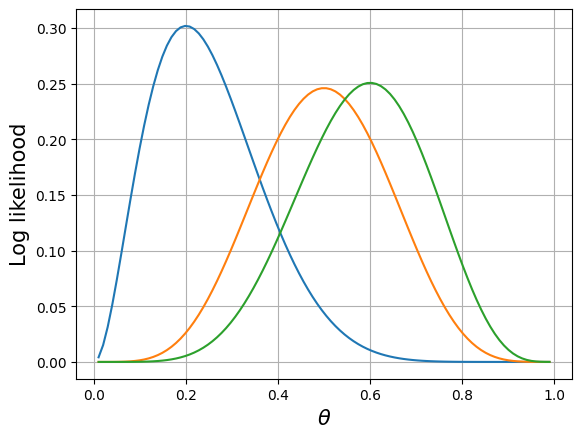

In [ ]:
lf_plot(10)

TypeError: legend() takes 0-2 positional arguments but 3 were given

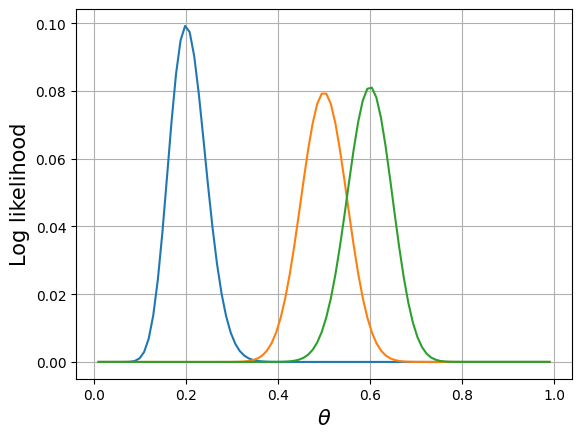

In [ ]:
lf_plot(100)

TypeError: legend() takes 0-2 positional arguments but 3 were given

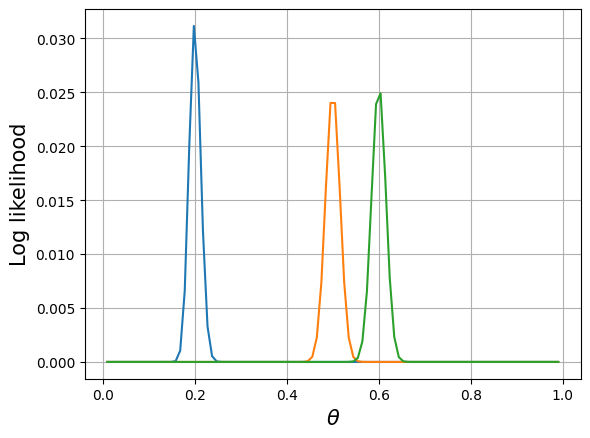

In [ ]:
lf_plot(1000)

The posterior distribution in Bayesian statistics combines the information in the likelihood and the prior.  Specifically, the posterior distribution is proportional to the likelihood times the prior.  The prior reflects the knowledge about the parameter that do not come from the data.  

When analyzing data using Bayesian methods, we can choose a prior.  A natural choice for the prior $p(\theta)$ for a binomial model is a uniform distribution on the unit interval $[0, 1]$.  In this case, the prior $p(\theta)$ is identically equal to 1, so the plots above showing likelihood functions also show the posterior distribution $p(\theta|D)$.

### **Beta priors**

Now suppose we have a strong reason to believe that our coin is fair, and wish to analyze the data in light of this prior knowledge.  To accomplish this, we can use a non-uniform prior that is concentrated around 1/2.  A convenient way to specify a prior for a parameter such as $\theta$, which is a probability that falls between 0 and 1, is to use a [beta distribution](https://en.wikipedia.org/wiki/Beta_distribution).  The beta distribution depends on two *shape parameters* $\alpha$ and $\beta$.  Below we graph the density function (pdf) of a beta distribution when $\alpha=\beta=2$.  This particular beta distribution places the greatest prior mass at 1/2, with symmetrically diminishing prior probability for values of $\theta$ close to either 0 or 1.  You can modify the values of $\alpha$ and $\beta$ to see the shape of the prior for other settings of the shape parameters.

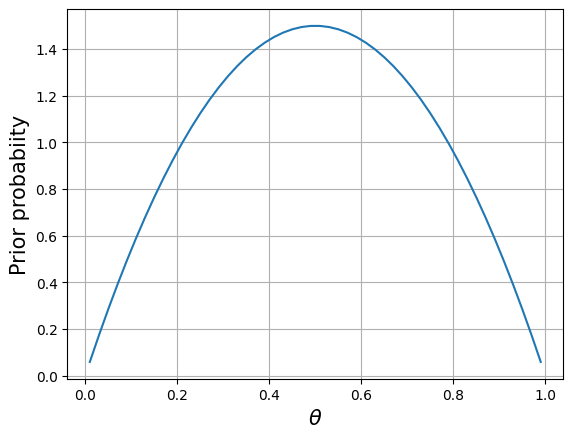

In [ ]:
alpha = 2
beta = 2
theta = np.linspace(0.01, 0.99)
plt.grid(True)
plt.plot(theta, st.beta.pdf(theta, alpha, beta))
plt.xlabel(r"$\theta$", size=15)
plt.ylabel("Prior probabiity", size=15);

The function below calculates the posterior distribution (up to a proportionality constant) for a dataset consisting of $x$ heads out of $n$ trials, using a Beta prior distribution with the given values of the shape parameters $\alpha$ and $\beta$.

In [ ]:
def post(x, n, alpha, beta, theta):
    return st.binom.pmf(x, n, theta) * st.beta.pdf(theta, alpha, beta)

The example below illustrates the difference between Bayesian and frequentist inference in this setting. If we observe  𝑥  heads out of  𝑛  tosses of the coin, we can use a Beta prior distribution with the given shape parameters to estimate  𝜃  (the true probability of the coin landing heads-up).
The blue and orange curves depict the posterior distribution for two different priors. In Bayesian analysis, the posterior distribution reflects all relevant information in the data about the parameter. Using a relatively flat prior ( 𝛼=𝛽=1 , orange curve) the posterior distribution has a peak very close to the MLE. The dispersion of the posterior distribution reflects the precision of this estimate. If we instead use a more concentrated prior with  𝛼=𝛽=10 , the mode of the posterior is shrunk toward the mean of the prior distribution, which is  1/2 . The posterior is also somewhat more concentrated as we are using a more concentrated prior.
The black horizontal line in the graph is the MLE, which always falls at  𝑥/𝑛 .

TypeError: legend() takes 0-2 positional arguments but 3 were given

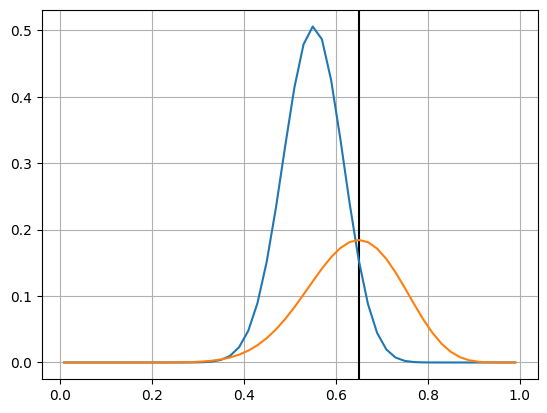

In [ ]:
x = 13
n = 20
plt.grid(True)
plt.axvline(x/n, color="black")
alpha, beta = 20, 20
po = post(x, n, 20, 20, theta)
plt.plot(theta, po, label="10,10")
alpha, beta = 1, 1
po = post(x, n, 1, 1, theta)
plt.plot(theta, po, label="1,1")
ha, lb = plt.gca().get_legend_handles_labels()
plt.figlegend(ha, lb, "center right")
plt.xlabel(r"$\theta$", size=15)
plt.ylabel("Posterior probability\n(not normalized)", size=15)

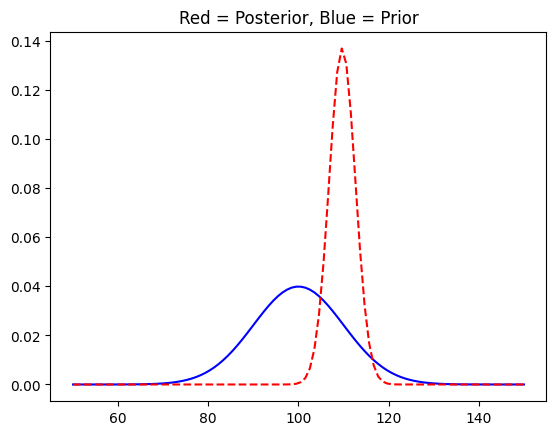

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import math
import scipy.stats as st

# Set a random seed for repeated computation
np.random.seed(123)

# Global constants - these are what we need to change
# This is my inital belief about the mean of the average IQ score on campus
prior_sigma = 10 # my uncertainty about the mean
prior_mean = 100 # my initial belief about the mean
sigma_observations = 3 # uncertainty in my observations

# New observations - We are going to be updating this list to see how observing
# different data changes our beliefs about the average IQ score
new_data = [110, 110, 110]

# Compute some statistics on the new data
n = len(new_data)

# Some hairy math to avoid doing integrals (Wikipedia has the math!)
if n != 0:
  posterior_mean = (( 1 / prior_sigma ** 2) + n / sigma_observations ** 2)**(-1) * ((prior_mean / prior_sigma ** 2) + sum(new_data) / sigma_observations ** 2)
  posterior_sd = (1 / prior_sigma ** 2 + n / sigma_observations ** 2)**(-1)
else:
  posterior_mean = prior_mean
  posterior_sd = prior_sigma

# Plot the distribution of the prior and the posterior
x = np.linspace(50, 150, 100)
plt.plot(x,st.norm.pdf(x, prior_mean, prior_sigma), color = "blue")
plt.plot(x,st.norm.pdf(x, posterior_mean, posterior_sd), color = "red", linestyle = '--')
plt.title("Red = Posterior, Blue = Prior")

# To view the graph, comment-out print(posterior_mean)
# To view the numerical output, comment-out plt.show()

plt.show()